<a href="https://colab.research.google.com/github/logansohm/Consciousness-Collapse-Reproducibility/blob/main/Survivability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook assumes the collapse parameters estimated in Notebook 1 and focuses exclusively on recovery and irreversibility.

k_hat = 0.4019788043525801
eta0_hat = 4.438879388110471

In [2]:

import os

for root, dirs, files in os.walk("/", topdown=True):
    for name in files:
        if "constructed" in name.lower():
            print(os.path.join(root, name))

/usr/include/boost/flyweight/detail/archive_constructed.hpp
/usr/include/boost/multi_index/detail/archive_constructed.hpp
/usr/local/lib/python3.12/dist-packages/tensorflow/include/google/protobuf/explicitly_constructed.h
/content/constructed_eta_R_dataset.csv
/tools/google-cloud-sdk/platform/gsutil/third_party/pyasn1/docs/source/pyasn1/type/base/constructedasn1type.rst


In [4]:

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

DATA_PATH = "/content/constructed_eta_R_dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Columns:", df.columns.tolist())

# Correct columns
eta_data = df["eta"].to_numpy(float)
R_data   = df["R"].to_numpy(float)

def logistic(eta, k, eta0):
    return 1.0 / (1.0 + np.exp(k * (eta - eta0)))

popt, pcov = curve_fit(
    logistic,
    eta_data,
    R_data,
    p0=[2.0, np.median(eta_data)],
    maxfev=10000
)

k_hat, eta0_hat = popt

print("\nFITTED PARAMETERS")
print("k_hat   =", k_hat)
print("eta0_hat=", eta0_hat)

Columns: ['domain', 'raw', 'eta', 'R', 'raw_ATA', 'raw_SpO2', 'raw_T', 'raw_C', 'raw_ETCO2']

FITTED PARAMETERS
k_hat   = 0.4019918135102278
eta0_hat= 4.438837546634042


Columns: ['domain', 'raw', 'eta', 'R', 'raw_ATA', 'raw_SpO2', 'raw_T', 'raw_C', 'raw_ETCO2']

FITTED COLLAPSE PARAMETERS
k_hat   = 0.4019788043525801
eta0_hat= 4.438879388110471


/tmp/ipython-input-3736995874.py:100: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  L = np.trapz(eta[mask], t[mask])
/tmp/ipython-input-3736995874.py:95: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  L = np.trapz(eta, t)



===== PAPER #2 RESULTS =====
AUC(integrated load L) = 1.0
AUC(peak eta)          = 0.8201686780204771
AUC(duration)          = 0.5


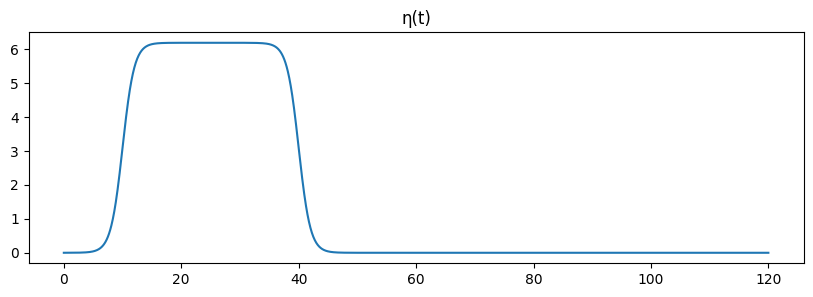

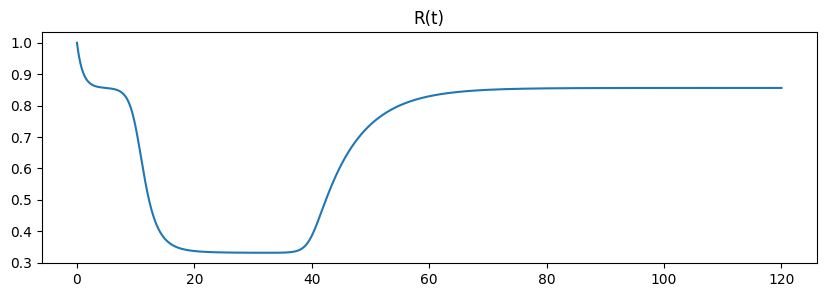

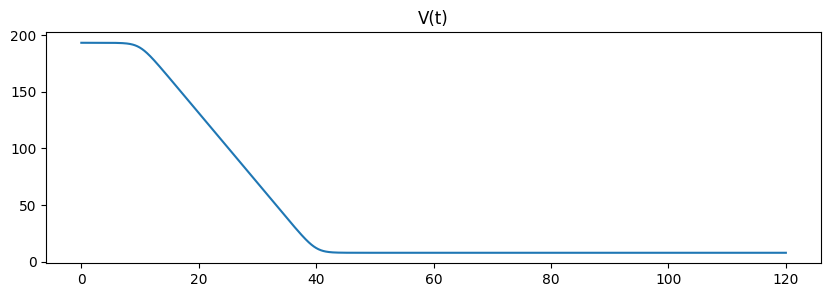

In [6]:

# =========================================================
# PAPER #1 → PAPER #2 COMPLETE PIPELINE (ONE CELL)
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------------
# 1) LOAD YOUR DATA
# ---------------------------------------------------------
DATA_PATH = "/content/constructed_eta_R_dataset.csv"
df = pd.read_csv(DATA_PATH)

print("Columns:", df.columns.tolist())

eta_data = df["eta"].to_numpy(float)
R_data   = df["R"].to_numpy(float)

# ---------------------------------------------------------
# 2) FIT COLLAPSE MANIFOLD (PAPER #1)
# ---------------------------------------------------------
def logistic(eta, k, eta0):
    return 1.0 / (1.0 + np.exp(k * (eta - eta0)))

popt, _ = curve_fit(
    logistic,
    eta_data,
    R_data,
    p0=[0.5, np.median(eta_data)],
    maxfev=10000
)

k_hat, eta0_hat = popt

print("\nFITTED COLLAPSE PARAMETERS")
print("k_hat   =", k_hat)
print("eta0_hat=", eta0_hat)

# ---------------------------------------------------------
# 3) PAPER #2 DYNAMICS
# ---------------------------------------------------------
R_star = 0.6  # operational closure threshold

def R_eq(eta):
    return 1.0 / (1.0 + np.exp(k_hat * (eta - eta0_hat)))

def eta_profile(t, amp=6.0, t_on=10.0, t_off=40.0, sharp=1.0):
    up   = 1.0 / (1.0 + np.exp(-(t - t_on) / sharp))
    down = 1.0 / (1.0 + np.exp(-(t - t_off) / sharp))
    return amp * (up - down)

def simulate_case(
    amp, V0,
    dt=0.05, T=120.0,
    t_on=10.0, t_off=40.0,
    alpha=1.0,
    tau_min=1.0,
    tau_gain=6.0
):
    t = np.arange(0, T + dt, dt)
    eta = eta_profile(t, amp=amp, t_on=t_on, t_off=t_off)

    R = np.zeros_like(t)
    V = np.zeros_like(t)
    R[0] = 1.0
    V[0] = V0

    t_ignite = None

    for i in range(1, len(t)):
        # viability depletion
        V[i] = max(0.0, V[i-1] - alpha * eta[i] * dt)

        # impedance-limited reconfiguration
        tau_adapt = tau_min + tau_gain * (1.0 - V[i] / max(V0, 1e-9))
        tau_adapt = max(tau_min, tau_adapt)

        R[i] = np.clip(
            R[i-1] + (R_eq(eta[i]) - R[i-1]) * (dt / tau_adapt),
            0.0, 1.0
        )

        if t[i] >= t_off and t_ignite is None and R[i] >= R_star:
            t_ignite = t[i]

        if V[i] <= 0.0 and t[i] >= t_off and t_ignite is None:
            break

    if t_ignite is None:
        outcome = 1   # persistent impairment
        tau = np.nan
        L = np.trapz(eta, t)
    else:
        outcome = 0   # recovery
        tau = t_ignite - t_off
        mask = (t >= t_on) & (t <= t_on + tau)
        L = np.trapz(eta[mask], t[mask])

    return {
        "outcome": outcome,
        "tau": tau,
        "L": L,
        "peak": float(np.max(eta)),
        "dur": t_off - t_on,
        "t": t,
        "eta": eta,
        "R": R,
        "V": V
    }

# ---------------------------------------------------------
# 4) RUN COHORT
# ---------------------------------------------------------
rng = np.random.default_rng(0)
rows = []
examples = []

for i in range(1000):
    amp = max(0.1, rng.normal(6.0, 1.5))
    V0  = max(20.0, rng.normal(200.0, 50.0))
    sim = simulate_case(amp, V0)
    rows.append({
        "outcome": sim["outcome"],
        "tau": sim["tau"],
        "L": sim["L"],
        "peak": sim["peak"],
        "dur": sim["dur"]
    })
    if i < 1:
        examples.append(sim)

df_sim = pd.DataFrame(rows)

# ---------------------------------------------------------
# 5) EVALUATE (THIS IS THE PAPER)
# ---------------------------------------------------------
y = df_sim["outcome"].to_numpy(int)

auc_L    = roc_auc_score(y, df_sim["L"])
auc_peak = roc_auc_score(y, df_sim["peak"])
auc_dur  = roc_auc_score(y, df_sim["dur"])

print("\n===== PAPER #2 RESULTS =====")
print("AUC(integrated load L) =", auc_L)
print("AUC(peak eta)          =", auc_peak)
print("AUC(duration)          =", auc_dur)

# ---------------------------------------------------------
# 6) SHOW ONE TRAJECTORY
# ---------------------------------------------------------
sim = examples[0]

plt.figure(figsize=(10,3))
plt.plot(sim["t"], sim["eta"])
plt.title("η(t)")
plt.show()

plt.figure(figsize=(10,3))
plt.plot(sim["t"], sim["R"])
plt.title("R(t)")
plt.show()

plt.figure(figsize=(10,3))
plt.plot(sim["t"], sim["V"])
plt.title("V(t)")
plt.show()

In [7]:

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

# ----- same fitted collapse params -----
k_hat   = 0.4019788043525801
eta0_hat= 4.438879388110471

def R_eq(eta):
    return 1.0 / (1.0 + np.exp(k_hat * (eta - eta0_hat)))

def eta_profile(t, amp=6.0, t_on=10.0, t_off=40.0, sharp=1.0):
    up   = 1.0 / (1.0 + np.exp(-(t - t_on) / sharp))
    down = 1.0 / (1.0 + np.exp(-(t - t_off) / sharp))
    return amp * (up - down)

def simulate_case_noisy(
    amp, V0_true,
    dt=0.05, T=120.0,
    t_on=10.0, t_off=40.0,
    alpha=1.0,
    tau_min=1.0, tau_gain=6.0,
    R_star_mu=0.6, R_star_sigma=0.05,
    R_noise_sigma=0.01,
    V_obs_noise_sigma=30.0
):
    rng = np.random.default_rng()

    t = np.arange(0, T + dt, dt)
    eta = eta_profile(t, amp=amp, t_on=t_on, t_off=t_off)

    # true viability dynamics
    R = np.zeros_like(t)
    V = np.zeros_like(t)
    R[0] = 1.0
    V[0] = V0_true

    # per-case noisy ignition threshold (measurement + subject)
    R_star = float(np.clip(rng.normal(R_star_mu, R_star_sigma), 0.3, 0.9))

    t_ignite = None

    for i in range(1, len(t)):
        V[i] = max(0.0, V[i-1] - alpha * eta[i] * dt)

        tau_adapt = tau_min + tau_gain * (1.0 - V[i] / max(V0_true, 1e-9))
        tau_adapt = max(tau_min, tau_adapt)

        # noisy R update to represent imperfect measurement / stochastic neural dynamics
        dR = (R_eq(eta[i]) - R[i-1]) * (dt / tau_adapt)
        R[i] = np.clip(R[i-1] + dR + rng.normal(0.0, R_noise_sigma), 0.0, 1.0)

        if t[i] >= t_off and t_ignite is None and R[i] >= R_star:
            t_ignite = t[i]

        if V[i] <= 0.0 and t[i] >= t_off and t_ignite is None:
            break

    # outcome still defined by true fate
    if t_ignite is None:
        outcome = 1
        tau_true = np.nan
    else:
        outcome = 0
        tau_true = t_ignite - t_off

    # what a modeler would "observe" for V0 (proxy noise)
    V0_obs = max(10.0, V0_true + rng.normal(0.0, V_obs_noise_sigma))

    # compute an "estimated" L using observed tau (if ignite) else full window
    if np.isnan(tau_true):
        L_est = np.trapezoid(eta, t)
    else:
        mask = (t >= t_on) & (t <= t_on + tau_true)
        L_est = np.trapezoid(eta[mask], t[mask])

    return {
        "outcome": outcome,
        "L": float(L_est),
        "peak": float(np.max(eta)),
        "dur": float(t_off - t_on),
        "V0_true": float(V0_true),
        "V0_obs": float(V0_obs),
        "R_star": R_star
    }

# run noisy cohort
rng = np.random.default_rng(0)
rows=[]
for i in range(2000):
    amp = max(0.1, rng.normal(6.0, 1.5))
    V0  = max(20.0, rng.normal(200.0, 50.0))
    rows.append(simulate_case_noisy(amp, V0))

dfN = pd.DataFrame(rows)

y = dfN["outcome"].to_numpy(int)
auc_L    = roc_auc_score(y, dfN["L"])
auc_peak = roc_auc_score(y, dfN["peak"])
auc_dur  = roc_auc_score(y, dfN["dur"])

print("===== NOISY ROBUSTNESS CHECK =====")
print("AUC(L)    =", auc_L)
print("AUC(peak) =", auc_peak)
print("AUC(dur)  =", auc_dur)
print("Chronic rate:", dfN["outcome"].mean())

===== NOISY ROBUSTNESS CHECK =====
AUC(L)    = 1.0
AUC(peak) = 0.8394920100782209
AUC(dur)  = 0.5
Chronic rate: 0.379


In [8]:

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

k_hat   = 0.4019788043525801
eta0_hat= 4.438879388110471

def R_eq(eta):
    return 1.0 / (1.0 + np.exp(k_hat * (eta - eta0_hat)))

def eta_profile(t, amp=6.0, t_on=10.0, t_off=40.0, sharp=1.0):
    up   = 1.0 / (1.0 + np.exp(-(t - t_on) / sharp))
    down = 1.0 / (1.0 + np.exp(-(t - t_off) / sharp))
    return amp * (up - down)

def simulate_case_var(
    amp, V0_true,
    t_on, t_off, sharp,
    dt=0.05, T=140.0,
    alpha=1.0,
    tau_min=1.0, tau_gain=6.0,
    R_star_mu=0.6, R_star_sigma=0.05,
    R_noise_sigma=0.01
):
    rng = np.random.default_rng()

    t = np.arange(0, T + dt, dt)
    eta = eta_profile(t, amp=amp, t_on=t_on, t_off=t_off, sharp=sharp)

    R = np.zeros_like(t)
    V = np.zeros_like(t)
    R[0] = 1.0
    V[0] = V0_true

    R_star = float(np.clip(rng.normal(R_star_mu, R_star_sigma), 0.3, 0.9))
    t_ignite = None

    for i in range(1, len(t)):
        V[i] = max(0.0, V[i-1] - alpha * eta[i] * dt)

        tau_adapt = tau_min + tau_gain * (1.0 - V[i] / max(V0_true, 1e-9))
        tau_adapt = max(tau_min, tau_adapt)

        dR = (R_eq(eta[i]) - R[i-1]) * (dt / tau_adapt)
        R[i] = np.clip(R[i-1] + dR + rng.normal(0.0, R_noise_sigma), 0.0, 1.0)

        if t[i] >= t_off and t_ignite is None and R[i] >= R_star:
            t_ignite = t[i]

        if V[i] <= 0.0 and t[i] >= t_off and t_ignite is None:
            break

    # outcome + tau
    if t_ignite is None:
        outcome = 1
        tau = np.nan
        # if never ignites, integrated load over whole window
        L = np.trapezoid(eta, t)
    else:
        outcome = 0
        tau = t_ignite - t_off
        mask = (t >= t_on) & (t <= t_on + tau)
        L = np.trapezoid(eta[mask], t[mask])

    dur = float(max(0.0, t_off - t_on))
    peak = float(np.max(eta))
    mean_eta = float(np.mean(eta[(t>=t_on) & (t<=t_off)]))  # insult-mean

    return dict(outcome=outcome, L=float(L), peak=peak, dur=dur, mean_eta=mean_eta, sharp=float(sharp))

# cohort with variable duration + shape
rng = np.random.default_rng(7)
rows=[]
for i in range(4000):
    amp = max(0.1, rng.normal(6.0, 1.8))
    V0  = max(20.0, rng.normal(200.0, 60.0))
    t_on  = float(rng.uniform(5.0, 20.0))
    dur   = float(rng.uniform(5.0, 80.0))
    t_off = t_on + dur
    sharp = float(rng.uniform(0.4, 3.0))
    rows.append(simulate_case_var(amp, V0, t_on, t_off, sharp))

dfV = pd.DataFrame(rows)
y = dfV["outcome"].to_numpy(int)

auc_L      = roc_auc_score(y, dfV["L"])
auc_peak   = roc_auc_score(y, dfV["peak"])
auc_dur    = roc_auc_score(y, dfV["dur"])
auc_mean   = roc_auc_score(y, dfV["mean_eta"])
auc_meanxd = roc_auc_score(y, dfV["mean_eta"] * dfV["dur"])

print("===== VARIABLE DURATION/SHAPE =====")
print("AUC(L)            =", auc_L)
print("AUC(peak)         =", auc_peak)
print("AUC(duration)     =", auc_dur)
print("AUC(mean eta)     =", auc_mean)
print("AUC(mean*duration)=", auc_meanxd)
print("Chronic rate:", dfV["outcome"].mean())

===== VARIABLE DURATION/SHAPE =====
AUC(L)            = 0.9999799761666323
AUC(peak)         = 0.7807980949324933
AUC(duration)     = 0.8360443517897177
AUC(mean eta)     = 0.8205313874839528
AUC(mean*duration)= 0.9392356752624811
Chronic rate: 0.51725


In [10]:

# ==============================
# EXPORT COHORT RESULTS (CSV)
# ==============================
csv_path = "paper2_variable_duration_results.csv"
dfV.to_csv(csv_path, index=False)

print("Wrote:", csv_path)
print("Rows:", len(dfV))
print("Columns:", dfV.columns.tolist())

Wrote: paper2_variable_duration_results.csv
Rows: 4000
Columns: ['outcome', 'L', 'peak', 'dur', 'mean_eta', 'sharp']


In [11]:

# ==============================
# EXPORT SUMMARY (JSON)
# ==============================
import json

results = {
    "paper": "Paper #2 – Recovery Boundary / Survivability",
    "collapse_parameters": {
        "k_hat": float(k_hat),
        "eta0_hat": float(eta0_hat)
    },
    "auc": {
        "integrated_load_L": float(auc_L),
        "peak_eta": float(auc_peak),
        "duration": float(auc_dur),
        "mean_eta": float(auc_mean),
        "mean_eta_x_duration": float(auc_meanxd)
    },
    "cohort": {
        "n_samples": int(len(dfV)),
        "chronic_rate": float(dfV["outcome"].mean())
    }
}

json_path = "paper2_summary.json"
with open(json_path, "w") as f:
    json.dump(results, f, indent=2)

print("Wrote:", json_path)

Wrote: paper2_summary.json


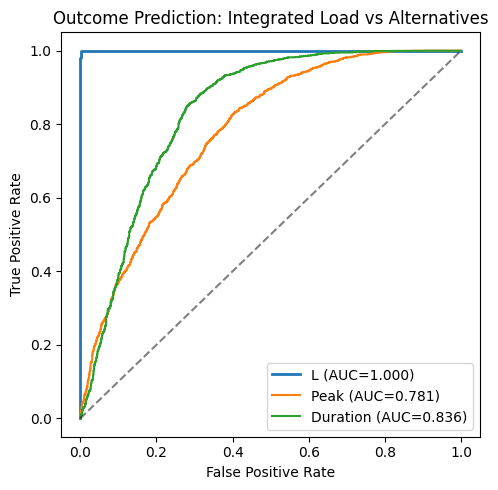

In [12]:

# ==============================
# FIGURE: ROC COMPARISON
# ==============================
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y = dfV["outcome"].to_numpy(int)

fpr_L, tpr_L, _ = roc_curve(y, dfV["L"])
fpr_peak, tpr_peak, _ = roc_curve(y, dfV["peak"])
fpr_dur, tpr_dur, _ = roc_curve(y, dfV["dur"])

plt.figure(figsize=(5,5))
plt.plot(fpr_L, tpr_L, label=f"L (AUC={auc_L:.3f})", linewidth=2)
plt.plot(fpr_peak, tpr_peak, label=f"Peak (AUC={auc_peak:.3f})")
plt.plot(fpr_dur, tpr_dur, label=f"Duration (AUC={auc_dur:.3f})")
plt.plot([0,1],[0,1],'k--',alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("Outcome Prediction: Integrated Load vs Alternatives")
plt.tight_layout()

plt.savefig("figure_roc_comparison.png", dpi=300)
plt.savefig("figure_roc_comparison.pdf")
plt.show()

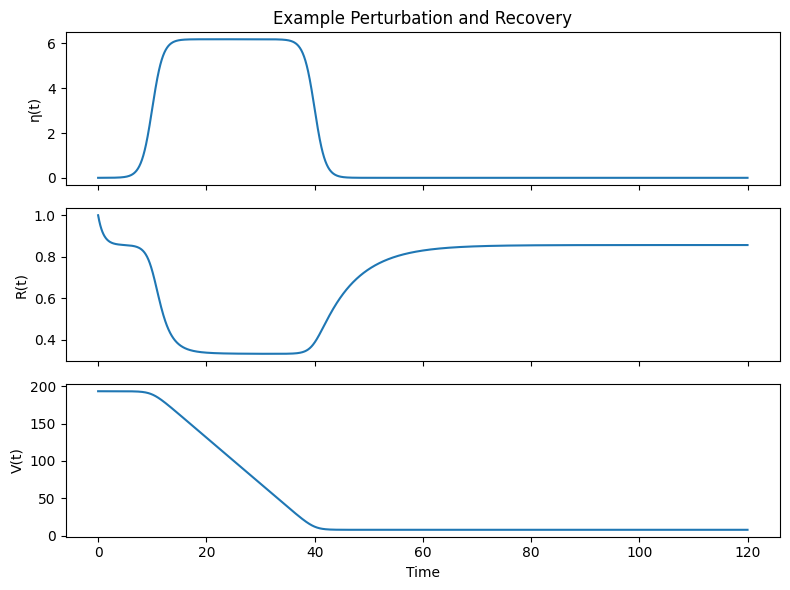

In [13]:

# ==============================
# FIGURE: EXAMPLE TRAJECTORY
# ==============================
sim = examples[0]

fig, axs = plt.subplots(3, 1, figsize=(8,6), sharex=True)

axs[0].plot(sim["t"], sim["eta"])
axs[0].set_ylabel("η(t)")
axs[0].set_title("Example Perturbation and Recovery")

axs[1].plot(sim["t"], sim["R"])
axs[1].set_ylabel("R(t)")

axs[2].plot(sim["t"], sim["V"])
axs[2].set_ylabel("V(t)")
axs[2].set_xlabel("Time")

plt.tight_layout()
plt.savefig("figure_example_trajectory.png", dpi=300)
plt.savefig("figure_example_trajectory.pdf")
plt.show()